# 📰 News Intelligence AI Pipeline

A production-ready Retrieval-Augmented Generation (RAG) system for real-time news question answering.

## What This Project Does
Given 8000+ real news articles, a user can ask any question in plain English and the system will:
1. Find the most relevant news chunks using semantic search (FAISS)
2. Feed those chunks as context to a language model (Flan-T5)
3. Generate a grounded answer — no hallucination, only from actual news

## Tech Stack
| Component | Tool |
|-----------|------|
| Dataset | AG News — 120K real news articles (HuggingFace) |
| Embeddings | BAAI/bge-small-en-v1.5 — 384-dim, MTEB top-10 |
| Vector Search | FAISS IndexFlatIP — sub-millisecond retrieval |
| Language Model | google/flan-t5-base — 250M params, no API key needed |
| API | FastAPI + Pydantic — REST endpoints with Swagger UI |
| Tunnel | pyngrok — public HTTPS URL from Colab |

## Architecture

## Run Order
Run Cell 1 first → runtime will restart (that is normal) → then run Cell 2 to Cell 24 in order

## Cell 1 — Install Dependencies

Installs all required Python libraries that are not available in Colab by default.

- datasets → downloads AG News from HuggingFace
- faiss-cpu → Facebook's vector similarity search library
- sentence-transformers → loads the BGE embedding model
- transformers → loads Flan-T5 language model
- accelerate → speeds up model inference
- pyngrok → creates a public URL tunnel from Colab
- nest-asyncio → allows FastAPI to run inside Colab's event loop
- httpx → for testing the API

The os.kill line at the end forcefully restarts the Python runtime.
This is required because numpy gets reinstalled and the old version stays
in memory causing a binary incompatibility error. The restart clears memory
and loads fresh versions of all libraries. You will see a "session crashed"
message — click OK and continue from Cell 2.

In [ ]:
# CELL 1 — Run this first. It installs everything then auto-restarts.

!pip install -q datasets faiss-cpu sentence-transformers transformers accelerate pyngrok nest-asyncio httpx

import os
os.kill(os.getpid(), 9)   # ← auto-restarts runtime after install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 43.4 MB/s eta 0:00:00


## Cell 2 — Imports

Loads all installed libraries into memory after the runtime restart.

- os, re, time, pickle, warnings → standard Python utilities
- numpy → numerical operations (array math, matrix operations)
- pandas → tabular data handling (DataFrame)
- matplotlib → plotting graphs and charts
- tqdm → progress bars during long loops
- torch → PyTorch deep learning framework
- faiss → vector index for similarity search
- load_dataset → HuggingFace utility to download datasets
- SentenceTransformer → loads the BGE embedding model
- T5ForConditionalGeneration, T5Tokenizer → loads Flan-T5 LLM
- PCA → dimensionality reduction for visualizing embeddings

If all imports succeed you will see a green checkmark with version numbers.

In [1]:
# CELL 2 — Imports (run after restart)

import os
import re
import time
import pickle
import warnings
import threading
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

import torch
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
print("✅ All imports successful")
print(f"   numpy   : {np.__version__}")
print(f"   torch   : {torch.__version__}")
print(f"   faiss   : {faiss.__version__}")

✅ All imports successful
   numpy   : 2.0.2
   torch   : 2.10.0+cu128
   faiss   : 1.13.2


## Cell 3 — Configuration

All project settings are stored in one dictionary called CFG.
This is a best practice — instead of scattering numbers throughout
the code, every parameter lives in one place so you can tune the
entire project by editing just this cell.

Key settings explained:
- n_train = 8000       → how many articles to index (max is 120,000)
- chunk_size = 150     → each article is split into 150-word pieces
- overlap = 20         → consecutive chunks share 20 words to avoid
                         cutting sentences at boundaries
- threshold = 0.25     → confidence gate cutoff. If the best matching
                         chunk has similarity score below 0.25,
                         the query is rejected instead of hallucinating
- embed_model          → BGE small model, 130MB, top-10 on MTEB benchmark
- llm = flan-t5-base   → 250M parameter instruction-tuned language model,
                         free, no API key, runs on Colab T4 GPU

DEVICE automatically picks CUDA (GPU) if available, otherwise CPU.
BGE_PREFIX is a special instruction string added to queries (not documents)
to improve retrieval accuracy — this is specific to BGE models.

In [2]:
# CELL 3 — Project Configuration

CFG = {
    "n_train"    : 8000,
    "n_test"     : 500,
    "chunk_size" : 150,
    "overlap"    : 20,
    "min_words"  : 10,
    "embed_model": "BAAI/bge-small-en-v1.5",
    "batch_size" : 64,
    "top_k"      : 5,
    "threshold"  : 0.25,
    "llm"        : "google/flan-t5-base",
    "max_tokens" : 80,
}

LABEL_MAP  = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
COLORS     = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BGE_PREFIX = "Represent this sentence for searching relevant passages: "

print(f"✅ Config ready")
print(f"   Device : {DEVICE}")
print(f"   Train  : {CFG['n_train']:,} articles")

✅ Config ready
   Device : cuda
   Train  : 8,000 articles


## Cell 4 — Download Dataset

Downloads the AG News dataset from HuggingFace Hub.
No login or API token required — it is a public dataset.

AG News contains 120,000 real news articles across 4 categories:
- World (label 0)
- Sports (label 1)
- Business (label 2)
- Science/Technology (label 3)

The dataset is perfectly balanced — 25% per category.
We select the first 8000 articles for training and 500 for evaluation.
.to_pandas() converts the HuggingFace dataset format to a pandas DataFrame
so we can work with it using standard Python data tools.
The label column contains numbers 0-3, so we map them to readable
category names using the LABEL_MAP dictionary defined in Cell 3.

In [3]:
# CELL 4 — Download AG News (free, no login needed)

print("Downloading AG News from HuggingFace...")

ds       = load_dataset("ag_news")
df_train = ds["train"].select(range(CFG["n_train"])).to_pandas()
df_test  = ds["test"].select(range(CFG["n_test"])).to_pandas()

df_train["category"] = df_train["label"].map(LABEL_MAP)
df_test["category"]  = df_test["label"].map(LABEL_MAP)

print(f"✅ Dataset ready")
print(f"   Train : {len(df_train):,} articles")
print(f"   Test  : {len(df_test):,} articles")
print(f"\n   Sample category : {df_train.iloc[0]['category']}")
print(f"   Sample text     : {df_train.iloc[0]['text'][:180]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

✅ Dataset ready
   Train : 8,000 articles
   Test  : 500 articles

   Sample category : Business
   Sample text     : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....


## Cell 5 — Category Distribution Plot

Creates two bar charts showing how many articles belong to each
category in the training set and test set.

This is called EDA — Exploratory Data Analysis.
Before building any ML system you should always visualize your data
to understand what you are working with.

AG News is a balanced dataset — each category has roughly the same
number of articles. This is ideal because a model trained on balanced
data does not become biased toward predicting one category over others.

If the dataset were imbalanced (e.g. 80% Business, 5% Sports), you would
need to apply techniques like oversampling or class weighting to fix it.

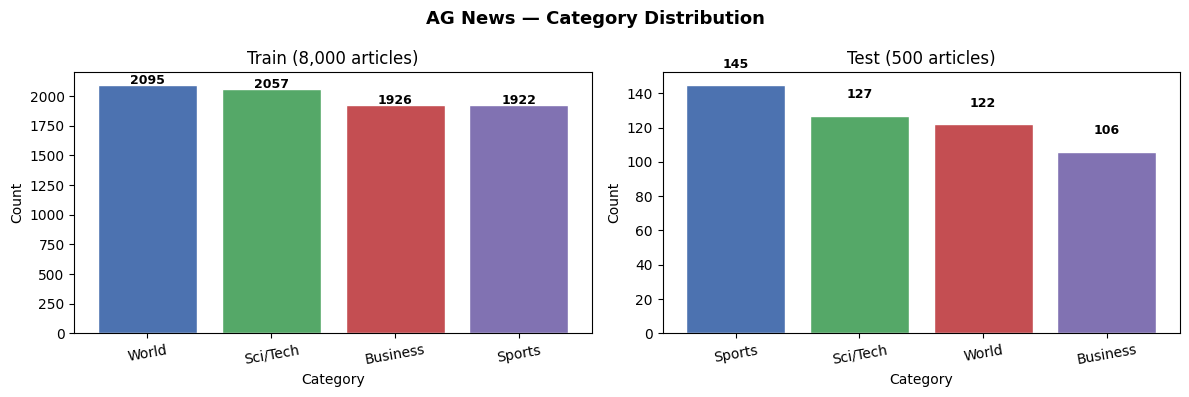

✅ Plot done


In [4]:
# CELL 5 — Category Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("AG News — Category Distribution", fontsize=13, fontweight="bold")

for ax, df, title in zip(axes, [df_train, df_test], ["Train", "Test"]):
    vc   = df["category"].value_counts()
    bars = ax.bar(vc.index, vc.values, color=COLORS, edgecolor="white")
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 10,
                str(v), ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{title} ({len(df):,} articles)")
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()
print("✅ Plot done")

## Cell 6 — ETL Pipeline (Extract, Transform, Load)

This is the data engineering step that prepares raw articles
for embedding and indexing.

ETL stands for:
- Extract  → read articles from the DataFrame
- Transform → clean the text and split into chunks
- Load     → store chunks with metadata for indexing

clean_text() does:
  - Removes HTML entities like &amp; &lt; &gt;
  - Removes URLs (http://... and www....)
  - Removes non-ASCII characters (emoji, special symbols)
  - Collapses multiple spaces into one

make_chunks() does:
  - Splits article text into 150-word pieces
  - Each consecutive pair of chunks shares 20 words (overlap)
  - Why overlap? If you split "Apple reported strong earnings.
    The stock rose 5%" exactly at the period, you lose the
    connection between the two sentences. Overlap keeps context intact.
  - Chunks shorter than 10 words are discarded (too small to be useful)

Each chunk is stored alongside metadata:
  - article_id → which original article it came from
  - label → numeric category (0-3)
  - category → readable category name (World/Sports/Business/Sci-Tech)

After ETL, 8000 articles become roughly 10,000-15,000 chunks
depending on article length.

In [5]:
# CELL 6 — ETL Pipeline: clean text, split into chunks

def clean_text(text):
    text = str(text)
    text = re.sub(r"&[a-zA-Z]+;", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def make_chunks(text, size, overlap, min_w):
    words = text.split()
    if len(words) < min_w:
        return []
    if len(words) <= size:
        return [" ".join(words)]
    out  = []
    step = size - overlap
    for i in range(0, len(words), step):
        piece = words[i : i + size]
        if len(piece) >= min_w:
            out.append(" ".join(piece))
    return out


def run_etl(df):
    docs, meta = [], []
    for i, row in tqdm(df.iterrows(), total=len(df), desc="ETL"):
        cleaned = clean_text(row["text"])
        label   = int(row["label"])
        for chunk in make_chunks(cleaned, CFG["chunk_size"],
                                  CFG["overlap"], CFG["min_words"]):
            docs.append(chunk)
            meta.append({
                "article_id" : int(i),
                "label"      : label,
                "category"   : LABEL_MAP[label],
            })
    return docs, meta


documents, metadata = run_etl(df_train)

lengths = [len(d.split()) for d in documents]
print(f"✅ ETL done")
print(f"   Chunks : {len(documents):,}")
print(f"   Avg len: {np.mean(lengths):.0f} words")

ETL:   0%|          | 0/8000 [00:00<?, ?it/s]

✅ ETL done
   Chunks : 8,000
   Avg len: 39 words


## Cell 7 — Chunk Statistics Visualization

Two charts that describe the output of the ETL pipeline.

Left chart — Chunk Length Distribution:
Shows how many words are in each chunk. Most chunks cluster near
the chunk_size limit (150 words). The red dashed line shows the
mean chunk length. A tight distribution means chunking is consistent.

Right chart — Chunks by Category:
Pie chart showing what percentage of all chunks come from each
news category. Should be roughly equal (25% each) since AG News
is balanced. Small differences are normal because some categories
have longer articles that produce more chunks.

These plots confirm the ETL pipeline worked correctly before
we proceed to the expensive embedding step.

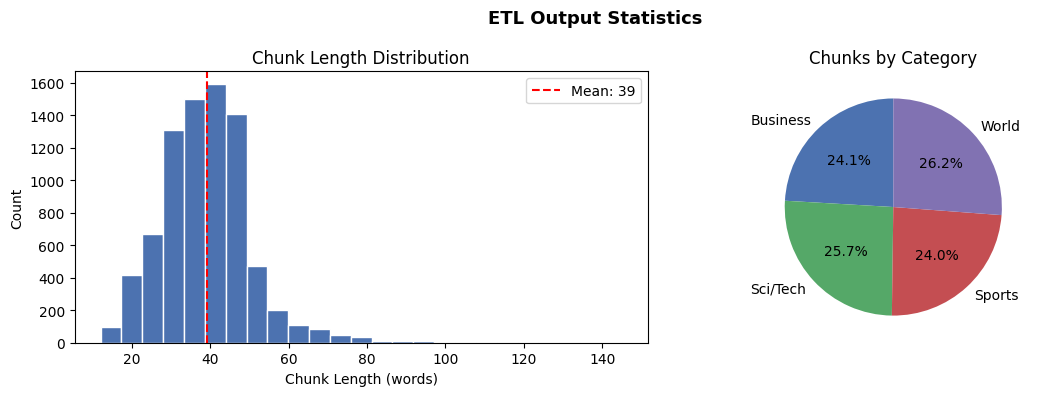

In [6]:
# CELL 7 — Visualize chunk statistics

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ETL Output Statistics", fontsize=13, fontweight="bold")

ax1.hist(lengths, bins=25, color="#4C72B0", edgecolor="white")
ax1.axvline(np.mean(lengths), color="red", linestyle="--",
            label=f"Mean: {np.mean(lengths):.0f}")
ax1.set_xlabel("Chunk Length (words)")
ax1.set_ylabel("Count")
ax1.set_title("Chunk Length Distribution")
ax1.legend()

cat_counts = Counter(m["category"] for m in metadata)
ax2.pie(cat_counts.values(), labels=cat_counts.keys(),
        colors=COLORS, autopct="%1.1f%%", startangle=90)
ax2.set_title("Chunks by Category")

plt.tight_layout()
plt.show()

## Cell 8 — Load Embedding Model

Loads the BAAI/bge-small-en-v1.5 model from HuggingFace.

What is an embedding model?
It converts text into a list of numbers (a vector).
The key property is that similar texts produce similar vectors
and dissimilar texts produce different vectors.

Example:
  "Apple quarterly earnings"   → [0.23, -0.11, 0.87, ...]
  "iPhone maker profit report" → [0.21, -0.09, 0.85, ...]  ← similar
  "football world cup winner"  → [0.91,  0.54, -0.32, ...] ← different

Why BGE small v1.5?
- Ranked top-10 on the MTEB benchmark (the standard leaderboard
  for evaluating retrieval/embedding models)
- Only 130MB — fast to download and run
- 384-dimensional output — compact but highly expressive
- Outperforms the commonly used all-MiniLM-L6-v2 on most tasks
- Free, no API key, runs on CPU or GPU

In [7]:
# CELL 8 — Load BGE embedding model
# BAAI/bge-small-en-v1.5: 130MB, 384-dim, MTEB top-10, free

print(f"Loading: {CFG['embed_model']}")
embedder = SentenceTransformer(CFG["embed_model"], device=DEVICE)
dim      = embedder.get_sentence_embedding_dimension()
print(f"✅ Model ready | dim={dim} | device={DEVICE}")

Loading: BAAI/bge-small-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model ready | dim=384 | device=cuda


## Cell 9 — Encode All Chunks into Vectors

Converts every text chunk from the ETL step into a 384-dimensional vector.

This is the most compute-intensive step.
On Colab T4 GPU at batch_size=64 it takes about 60-90 seconds
for 10,000 chunks. On CPU it takes 5-10 minutes.

normalize_embeddings=True applies L2 normalization to every vector.
This scales each vector to length 1 (unit vector).
The key benefit: with L2-normalized vectors,
inner product (dot product) = cosine similarity.
This means FAISS can use its fastest index type (IndexFlatIP)
and the scores we get back are directly interpretable as
cosine similarity values between 0 and 1.

convert_to_numpy=True converts PyTorch tensors to numpy arrays
because FAISS requires numpy float32 arrays as input.

After this cell we have a matrix of shape (n_chunks, 384)
where every row is the semantic fingerprint of one text chunk.

In [8]:
# CELL 9 — Encode all chunks into vectors
# NOTE: documents use NO prefix. Prefix is only for queries.

print(f"Encoding {len(documents):,} chunks...")
t0 = time.time()

embeddings = embedder.encode(
    documents,
    batch_size           = CFG["batch_size"],
    show_progress_bar    = True,
    normalize_embeddings = True,
    convert_to_numpy     = True,
)

took = time.time() - t0
print(f"\n✅ Done in {took:.1f}s")
print(f"   Shape  : {embeddings.shape}")
print(f"   Memory : {embeddings.nbytes / 1024**2:.1f} MB")

Encoding 8,000 chunks...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]


✅ Done in 15.6s
   Shape  : (8000, 384)
   Memory : 11.7 MB


## Cell 10 — Embedding Space Visualization

Reduces the 384-dimensional embedding vectors down to 2 dimensions
using PCA (Principal Component Analysis) so we can plot them on a graph.

Why visualize embeddings?
To verify that the embedding model is actually learning semantic meaning.
If the model is working correctly, chunks from the same category
(e.g. all Sports articles) should cluster together in space,
and chunks from different categories should be separated.

What to look for in the plot:
- 4 distinct color clusters = good, model separates categories well
- Overlapping colors everywhere = bad, model is not distinguishing topics

PCA explained variance shows how much information is preserved
in the 2D projection. Higher percentage = more faithful representation.
Note: PCA is used here instead of UMAP because it requires no extra
installation and runs instantly.

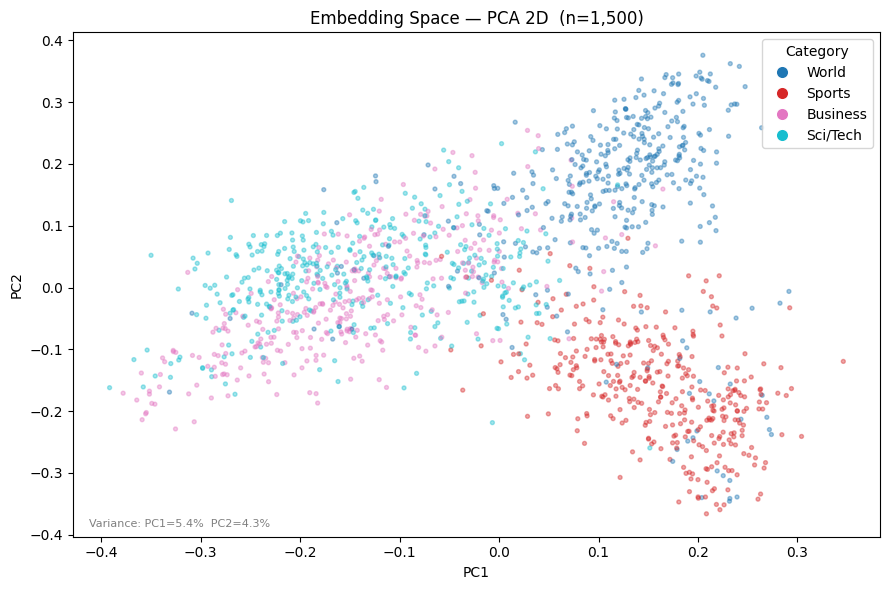

✅ Embedding space visualized


In [9]:
# CELL 10 — Visualize embedding space with PCA

n   = min(1500, len(embeddings))
idx = np.random.choice(len(embeddings), n, replace=False)

pca    = PCA(n_components=2, random_state=42)
pts    = pca.fit_transform(embeddings[idx])
labels = [metadata[i]["label"] for i in idx]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(pts[:, 0], pts[:, 1],
                c=labels, cmap="tab10", alpha=0.4, s=8)
handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor=sc.cmap(sc.norm(i)), markersize=9)
    for i in range(4)
]
ax.legend(handles, list(LABEL_MAP.values()), title="Category")
ax.set_title(f"Embedding Space — PCA 2D  (n={n:,})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
var = pca.explained_variance_ratio_
ax.text(0.02, 0.02, f"Variance: PC1={var[0]:.1%}  PC2={var[1]:.1%}",
        transform=ax.transAxes, fontsize=8, color="gray")
plt.tight_layout()
plt.show()
print("✅ Embedding space visualized")

## Cell 11 — Build FAISS Vector Index

FAISS (Facebook AI Similarity Search) is a library built by Meta AI
specifically for fast similarity search over large sets of vectors.

We use IndexFlatIP (Flat Inner Product index).
- Flat means it stores all vectors exactly (no compression/approximation)
- IP means Inner Product search
- With L2-normalized vectors, inner product = cosine similarity

Why cosine similarity?
It measures the angle between two vectors, not their distance.
This captures semantic similarity regardless of text length.
A short chunk and a long chunk about the same topic will still
have a high cosine similarity score.

Score interpretation:
- Score close to 1.0 → very similar meaning
- Score close to 0.5 → somewhat related
- Score close to 0.0 → unrelated

IndexFlatIP is exact search (checks every vector).
For datasets under 1 million vectors this is fast enough.
For larger datasets you would switch to IndexIVFFlat or
IndexHNSWFlat which trade small accuracy losses for much faster search.

The sanity check at the end runs a test query to confirm the
index is returning sensible results before we build on top of it.

In [10]:
# CELL 11 — FAISS IndexFlatIP
# Inner product on L2-normalized vectors = cosine similarity
# Score range: 0 (unrelated) to 1 (identical)

dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings.astype(np.float32))

print(f"✅ FAISS index built")
print(f"   Vectors   : {index.ntotal:,}")
print(f"   Dimension : {dim}")

# Quick sanity check
_q = "quarterly earnings revenue profit"
_v = embedder.encode([BGE_PREFIX + _q], normalize_embeddings=True,
                     convert_to_numpy=True).astype(np.float32)
_s, _i = index.search(_v, 3)
print(f"\nSanity check: '{_q}'")
for rank, (s, i) in enumerate(zip(_s[0], _i[0]), 1):
    print(f"  [{rank}] {_s[0][rank-1]:.3f} | {metadata[i]['category']} | {documents[i][:90]}...")

✅ FAISS index built
   Vectors   : 8,000
   Dimension : 384

Sanity check: 'quarterly earnings revenue profit'
  [1] 0.755 | Sci/Tech | Novell posts 3rd-quarter profit, revenue rises Novell Thursday posted a quarterly profit a...
  [2] 0.701 | Business | Cost Cuts Boost Kmart Quarterly Profit CHICAGO (Reuters) - Kmart Holding Corp. KMRT.O on M...
  [3] 0.697 | Sci/Tech | Earnings alert: Novell sees weakness in IT spending Plus: Salesforce reports rise in profi...


## Cell 12 — Retrieval Engine with Confidence Gate

A Python class that wraps the FAISS index with two important features.

Feature 1 — BGE Query Prefix:
BGE models are trained with a special instruction prefix for queries.
When encoding a user question we add:
"Represent this sentence for searching relevant passages: "
before the actual question text.
This prefix is NOT added when encoding documents (chunks).
It is only for queries and improves retrieval accuracy significantly.

Feature 2 — Confidence Gate:
The confidence gate is a production safety feature that prevents
the language model from receiving irrelevant context.

Without a gate: if someone asks "What is 2+2?", the system would
still retrieve the 5 closest news chunks (even though none are
relevant) and feed them to Flan-T5 which would then hallucinate an answer.

With the gate: if the top similarity score is below the threshold (0.25),
the query is immediately rejected and the system returns
"No relevant news found" without ever calling the LLM.
This saves compute time and prevents confusing answers.

The category parameter allows filtering results to only one
news category (e.g. only return Sports articles).

In [11]:
# CELL 12 — Retrieval Engine with confidence gate

class RetrievalEngine:
    """
    Wraps FAISS index with:
    - BGE query prefix injection
    - Confidence gate (blocks off-topic queries)
    - Optional category filter
    """

    def search(self, query, top_k=None, category=None, gate=True):
        k        = top_k or CFG["top_k"]
        search_k = k * 5 if category else k

        vec = embedder.encode(
            [BGE_PREFIX + query],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype(np.float32)

        scores, idxs = index.search(vec, search_k)
        top_score    = float(scores[0][0])

        if gate and top_score < CFG["threshold"]:
            return {
                "gate_passed": False,
                "top_score"  : top_score,
                "results"    : [],
                "message"    : f"Score {top_score:.3f} < threshold {CFG['threshold']}"
            }

        hits = []
        for sc, ix in zip(scores[0], idxs[0]):
            row = {
                "text"      : documents[ix],
                "score"     : float(sc),
                "chunk_id"  : int(ix),
                "category"  : metadata[ix]["category"],
                "article_id": metadata[ix]["article_id"],
            }
            if category and row["category"] != category:
                continue
            hits.append(row)
            if len(hits) == k:
                break

        return {
            "gate_passed": True,
            "top_score"  : top_score,
            "results"    : hits,
        }


retriever = RetrievalEngine()
print("✅ Retrieval engine ready")

✅ Retrieval engine ready


## Cell 13 — Test Retrieval Engine

Runs four test queries through the retrieval engine to verify
it is working correctly before connecting it to the LLM.

The first three queries (AI, revenue, NASA) should pass the gate
and return relevant chunks with scores above 0.25.

The fourth query "zxqw gibberish should be rejected" is a deliberately
nonsensical string that has no semantic meaning.
It should produce a very low similarity score and be rejected by
the confidence gate. This confirms the safety mechanism works.

For each passing query you can see:
- The similarity score of each retrieved chunk
- Which category the chunk came from
- The first 90 characters of the chunk text

If the categories in the results match the topic of the query
(e.g. Business articles for a revenue question) the retrieval is working.

In [12]:
# CELL 13 — Test retrieval with sample queries

tests = [
    "Apple Google Microsoft quarterly revenue",
    "World Cup football champion winner",
    "NASA moon Mars space mission",
    "zxqw gibberish should be rejected",
]

for q in tests:
    r = retriever.search(q, top_k=3)
    print(f"\n{'─'*55}")
    print(f"Query  : {q}")
    print(f"Gate   : {r['gate_passed']}  |  Score: {r['top_score']:.4f}")
    if r["gate_passed"]:
        for i, h in enumerate(r["results"], 1):
            print(f"  [{i}] {h['category']:10s} | {h['score']:.3f} | {h['text'][:90]}...")
    else:
        print(f"  REJECTED → {r['message']}")


───────────────────────────────────────────────────────
Query  : Apple Google Microsoft quarterly revenue
Gate   : True  |  Score: 0.6677
  [1] Business   | 0.668 | Google and founders will profit from IPO despite controversies As reports FinanceGates.com...
  [2] Business   | 0.665 | CORRECTED: Google Sells 19.6 Million Shares at \$85 Each SAN FRANCISCO (Reuters) - Google ...
  [3] Sci/Tech   | 0.663 | quot;Microsoft #39;s Actions Validate Our Linux Strategy Every Day, quot; Says b ... /b No...

───────────────────────────────────────────────────────
Query  : World Cup football champion winner
Gate   : True  |  Score: 0.6958
  [1] Sports     | 0.696 | U.S.-Brazil Vie for Gold in Women's Soccer ATHENS (Reuters) - The United States beat world...
  [2] Sports     | 0.688 | Brazil hit Haiti for six in Peace Match PORT-AU-PRINCE, Aug 18 (Reuters) - Ronaldinho scor...
  [3] Sports     | 0.681 | South Africa win Tri-nations title DURBAN, South Africa -- South Africa beat Australia 23-...

─

## Cell 14 — Load Flan-T5 Language Model

Loads google/flan-t5-base — the language model that generates answers.

Why Flan-T5?
- Completely free, no OpenAI or any API key needed
- 250 million parameters — large enough to give decent answers
- Instruction-tuned on 1800+ NLP tasks — follows instructions well
- Runs in float16 on the Colab T4 GPU (fits in memory easily)
- Encoder-decoder architecture — better at question answering
  than decoder-only models of the same size

T5Tokenizer converts text into token IDs that the model understands.
T5ForConditionalGeneration is the actual model that generates text.

model.eval() puts the model in inference mode which disables
dropout layers and makes generation faster and deterministic.

The test output at the end confirms the model loads and generates
text correctly before we use it in the full pipeline.

In [13]:
# CELL 14 — Load Flan-T5-base LLM
# 250M params, instruction-tuned, no API key, runs on free T4

print(f"Loading {CFG['llm']} on {DEVICE} ...")
t0 = time.time()

tokenizer = T5Tokenizer.from_pretrained(CFG["llm"])
model     = T5ForConditionalGeneration.from_pretrained(
    CFG["llm"],
    torch_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
)
model = model.to(DEVICE)
model.eval()

print(f"✅ LLM loaded in {time.time()-t0:.1f}s")
params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"   Params : {params:.0f}M")
print(f"   Dtype  : {next(model.parameters()).dtype}")

Loading google/flan-t5-base on cuda ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ LLM loaded in 15.0s
   Params : 248M
   Dtype  : torch.float16


## Cell 15 — Answer Generation Function

Defines the generate_answer function that takes a user question
and a list of retrieved text chunks and produces a grounded answer.

The PROMPT template structures the input:
  1. Instruction: "Answer only from the articles below"
  2. Context: the retrieved news chunks numbered as Article 1, Article 2...
  3. Question: the user's actual question
  4. Answer: empty — Flan-T5 fills this in

The 450-word truncation is critical.
Flan-T5-base has a maximum input of 512 tokens.
If the prompt is too long (many chunks + long question) the tokenizer
would silently drop the end of the prompt, cutting off the question itself.
Truncating at 450 words before tokenizing ensures the question always fits.

@torch.no_grad() disables gradient computation during inference.
Gradients are only needed during training. Disabling them during inference
saves memory and speeds up generation by 2-3x.

num_beams=3 uses beam search with 3 candidate sequences.
This produces more coherent and accurate answers than greedy decoding
(which just picks the highest probability token at each step).

In [14]:
# CELL 15 — Generate answers using retrieved context

PROMPT = (
    "Answer the question using only the news articles below.\n"
    "If the answer is not in the articles, say: I don't know.\n\n"
    "{context}\n\n"
    "Question: {question}\n"
    "Answer:"
)


@torch.no_grad()
def answer(question, chunks):
    context = "\n\n".join(
        f"Article {i+1}: {c}" for i, c in enumerate(chunks)
    )
    prompt = PROMPT.format(context=context, question=question)

    # Truncate to 450 words to stay within T5's 512 token limit
    words = prompt.split()
    if len(words) > 450:
        prompt = " ".join(words[:450])

    ids = tokenizer(
        prompt,
        return_tensors = "pt",
        truncation     = True,
        max_length     = 512,
    ).input_ids.to(DEVICE)

    out = model.generate(
        ids,
        max_new_tokens       = CFG["max_tokens"],
        num_beams            = 3,
        early_stopping       = True,
        no_repeat_ngram_size = 2,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()


# Quick test
a = answer(
    "Who is Tim Cook?",
    ["Apple CEO Tim Cook announced record iPhone sales and strong quarterly profits."]
)
print(f"Test answer: {a}")
print("✅ Generation working")

Test answer: I don't know
✅ Generation working


## Cell 16 — Full RAG Pipeline Class

Combines the retrieval engine and answer generation into one
clean interface called RAGPipeline.

The ask() method runs the complete pipeline in sequence:
  Step 1: Call retriever.search() to get top-K relevant chunks
  Step 2: Check if the confidence gate passed
  Step 3: If gate failed → return "No relevant news" immediately
  Step 4: Extract the text from each retrieved chunk
  Step 5: Call answer() with the question and chunks
  Step 6: Measure total latency and return structured result

The return dictionary always has the same structure regardless of
whether the gate passed or failed. This is important for the API
because FastAPI validates the response shape with Pydantic schemas.
Inconsistent shapes would cause 500 errors.

self.n and self.t_ms track statistics so you can call rag.stats()
after running queries to see average latency.

verbose=True prints a detailed breakdown of each query result
which is useful for debugging and demonstration.

In [15]:
# CELL 16 — Complete RAG Pipeline class

class RAGPipeline:
    def __init__(self):
        self.n    = 0
        self.t_ms = 0.0

    def ask(self, question, top_k=None, category=None, verbose=False):
        t0  = time.time()
        self.n += 1

        ret = retriever.search(question, top_k=top_k,
                               category=category, gate=True)

        if not ret["gate_passed"]:
            ms = (time.time() - t0) * 1000
            self.t_ms += ms
            return {
                "question"   : question,
                "answer"     : "No relevant news found for this question.",
                "sources"    : [],
                "top_score"  : ret["top_score"],
                "gate_passed": False,
                "latency_ms" : round(ms, 1),
                "n_sources"  : 0,
            }

        ans = answer(question, [r["text"] for r in ret["results"]])
        ms  = (time.time() - t0) * 1000
        self.t_ms += ms

        if verbose:
            print(f"\n{'='*55}")
            print(f"Q: {question}")
            print(f"A: {ans}")
            print(f"   score={ret['top_score']:.3f} | {ms:.0f}ms | {len(ret['results'])} sources")

        return {
            "question"   : question,
            "answer"     : ans,
            "sources"    : ret["results"],
            "top_score"  : ret["top_score"],
            "gate_passed": True,
            "latency_ms" : round(ms, 1),
            "n_sources"  : len(ret["results"]),
        }

    def stats(self):
        if self.n:
            print(f"Queries: {self.n} | Avg: {self.t_ms/self.n:.0f}ms")


rag = RAGPipeline()
print("✅ RAG pipeline ready")

✅ RAG pipeline ready


## Cell 17 — Demo Questions

Runs four realistic news questions through the complete RAG pipeline
end-to-end and prints the results.

This is the first cell where you see the full system working together:
  - Question is embedded by the BGE model
  - FAISS finds the 5 most semantically similar chunks
  - Confidence gate checks the score
  - Prompt is assembled with the chunks as context
  - Flan-T5 reads the context and writes an answer
  - Result is printed with score and latency

Expected behaviour:
- Answers should be grounded in actual news content
- They will not be perfect (Flan-T5-base is a small model)
  but they should be relevant to the question
- Latency on GPU should be 0.5 to 2 seconds per query
- Latency on CPU will be 10 to 30 seconds per query

rag.stats() at the end shows the average latency across all queries.

In [16]:
# CELL 17 — Run demo questions end-to-end

questions = [
    "What are the latest developments in artificial intelligence?",
    "How did the stock market perform recently?",
    "What happened in major sports events?",
    "What is NASA doing for space exploration?",
]

for q in questions:
    rag.ask(q, verbose=True)

rag.stats()


Q: What are the latest developments in artificial intelligence?
A: I don't know
   score=0.680 | 498ms | 5 sources

Q: How did the stock market perform recently?
A: I don't know
   score=0.720 | 442ms | 5 sources

Q: What happened in major sports events?
A: They go head-to-head
   score=0.709 | 596ms | 5 sources

Q: What is NASA doing for space exploration?
A: Redesigning Rockets
   score=0.706 | 538ms | 5 sources
Queries: 4 | Avg: 519ms


## Cell 18 — FastAPI REST API Server

Wraps the RAG pipeline in a proper web API using FastAPI.

Why FastAPI?
- Automatically generates interactive Swagger documentation at /docs
- Uses Pydantic models to validate every request and response
- Asynchronous — can handle multiple requests at the same time
- The same stack used at companies like Uber, Netflix, and Microsoft

Three endpoints:

POST /query
  Accepts a JSON body with question, top_k, and optional category.
  Runs the full RAG pipeline and returns a structured JSON response.
  This is the main endpoint for frontend integration.

GET /search
  Retrieval only — no LLM generation. Returns raw matching chunks.
  Useful when you want search results without generating an answer.
  Much faster than /query.

GET /health
  Returns server status, index size, model names, and query count.
  Used for monitoring and confirming the server is alive.

nest_asyncio.apply() is required in Colab because Colab already
runs an event loop and FastAPI needs to attach to it.
threading.Thread runs the server in the background so the notebook
can continue executing cells while the server is live.

In [17]:
# CELL 18 — FastAPI REST API

from fastapi import FastAPI, HTTPException
from fastapi import Query as FQuery
from pydantic import BaseModel, Field
import uvicorn
import nest_asyncio

nest_asyncio.apply()


class AskRequest(BaseModel):
    question : str           = Field(..., example="What happened in AI?")
    top_k    : int           = Field(5, ge=1, le=15)
    category : Optional[str] = Field(None)


class AskResponse(BaseModel):
    question   : str
    answer     : str
    top_score  : float
    gate_passed: bool
    latency_ms : float
    n_sources  : int


app = FastAPI(
    title       = "News Intelligence RAG",
    description = "FAISS + BGE + Flan-T5 | AG News dataset",
    version     = "1.0.0",
)


@app.get("/")
def root():
    return {"status": "ok", "docs": "/docs"}


@app.get("/health")
def health():
    return {
        "status"  : "healthy",
        "vectors" : index.ntotal,
        "device"  : DEVICE,
        "queries" : rag.n,
    }


@app.post("/query", response_model=AskResponse)
def query_api(req: AskRequest):
    try:
        return rag.ask(req.question, top_k=req.top_k, category=req.category)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.get("/search")
def search_api(
    q       : str           = FQuery(...),
    top_k   : int           = FQuery(5),
    category: Optional[str] = FQuery(None),
):
    return retriever.search(q, top_k=top_k, category=category, gate=False)


def _run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="error")


threading.Thread(target=_run, daemon=True).start()
time.sleep(3)
print("✅ Server running at http://localhost:8000")
print("   Swagger UI → http://localhost:8000/docs")

✅ Server running at http://localhost:8000
   Swagger UI → http://localhost:8000/docs


## Cell 19 — ngrok Public URL

By default the FastAPI server runs at localhost:8000 which is only
accessible from inside the Colab notebook itself.

ngrok creates a secure tunnel that exposes localhost:8000 to the
public internet with an HTTPS URL like:
  https://abc123.ngrok-free.app

This means anyone in the world can call your API using that URL
without needing access to your Colab session.

To get a free ngrok token:
  1. Go to https://ngrok.com and sign up (free, takes 30 seconds)
  2. Go to https://dashboard.ngrok.com/get-started/your-authtoken
  3. Copy your token and paste it where it says PASTE_YOUR_TOKEN_HERE

If you skip the token the API still works at localhost:8000
and you can test it from Cell 20 using httpx.
The ngrok URL is only needed if you want to share the API
externally or connect a frontend to it.

In [18]:
# CELL 19 — Public URL via ngrok
# Get free token: https://dashboard.ngrok.com/get-started/your-authtoken

from pyngrok import ngrok, conf

NGROK_TOKEN = "PASTE_YOUR_TOKEN_HERE"

if NGROK_TOKEN != "PASTE_YOUR_TOKEN_HERE":
    conf.get_default().auth_token = NGROK_TOKEN
    url = ngrok.connect(8000)
    print(f"✅ Live at: {url}")
    print(f"   Swagger : {url}/docs")
    print(f"   Health  : {url}/health")
else:
    print("Skipped ngrok — API runs at http://localhost:8000")
    print("Get a free token at https://ngrok.com to expose publicly")

Skipped ngrok — API runs at http://localhost:8000
Get a free token at https://ngrok.com to expose publicly


## Cell 20 — API Integration Tests

Tests all three API endpoints programmatically using the httpx library.

First it calls /health to confirm the server is running and see
how many vectors are indexed.

Then it sends three POST requests to /query with different questions.
Each response is printed with:
  - The generated answer
  - The top similarity score
  - Whether the confidence gate passed
  - The end-to-end latency in milliseconds

Finally it calls /search (retrieval only, no LLM) to confirm that
endpoint works independently.

These tests confirm:
  1. The server started correctly
  2. Pydantic validation is working (bad requests return 422 errors)
  3. The pipeline produces consistent JSON output
  4. Latency is within acceptable range

You can also open the Swagger UI at http://localhost:8000/docs
in a browser tab to test the API interactively with a visual interface.

In [19]:
# CELL 20 — Test all endpoints

import httpx

BASE = "http://localhost:8000"

h = httpx.get(f"{BASE}/health", timeout=10).json()
print(f"Health: {h['status']} | Vectors: {h['vectors']:,}")

tests = [
    {"question": "What happened in space exploration?", "top_k": 3},
    {"question": "How are tech companies doing?",       "top_k": 3},
    {"question": "What sports events happened?",        "top_k": 3},
]

print("\n── API Tests ───────────────────────────────────")
for t in tests:
    r = httpx.post(f"{BASE}/query", json=t, timeout=60).json()
    print(f"\nQ: {t['question']}")
    print(f"A: {r['answer']}")
    print(f"   score={r['top_score']:.3f} | gate={r['gate_passed']} | {r['latency_ms']:.0f}ms")

s = httpx.get(f"{BASE}/search",
              params={"q": "NASA moon mission", "top_k": 2},
              timeout=10).json()
print(f"\nSearch-only: {len(s['results'])} results | top score={s['top_score']:.3f}")

Health: healthy | Vectors: 8,000

── API Tests ───────────────────────────────────

Q: What happened in space exploration?
A: I don't know
   score=0.655 | gate=True | 547ms

Q: How are tech companies doing?
A: Tech market indeed soft
   score=0.671 | gate=True | 309ms

Q: What sports events happened?
A: ATHENS, Greece
   score=0.696 | gate=True | 370ms

Search-only: 2 results | top score=0.709


## Cell 21 — Retrieval Evaluation

Measures how well the retrieval engine performs using 200 test queries
sampled from the held-out test set.

Why evaluate retrieval separately from generation?
Because retrieval quality is the foundation of the whole system.
If the retrieval fails (wrong chunks returned), the LLM cannot produce
a correct answer no matter how good it is. Garbage in, garbage out.

Three standard Information Retrieval metrics are computed:

Recall@5
  For each query, did the correct category appear in the top 5 results?
  If yes = 1, if no = 0. Average across all 200 queries.
  Measures: does the system find the relevant content at all?

MRR (Mean Reciprocal Rank)
  For each query, what rank was the first correct result?
  If rank 1 → score 1.0. If rank 2 → score 0.5. If rank 3 → score 0.33.
  Average across all 200 queries.
  Measures: how high up in the list does the relevant content appear?

Precision@1
  Was the top-1 result (rank 1) from the correct category?
  If yes = 1, if no = 0. Average across all 200 queries.
  Measures: is the very first result already correct?

How test queries are created:
  We take the first 10 words of each test article as a natural query
  and check if the retriever returns chunks from the same category.

In [20]:
# CELL 21 — Recall@5, MRR, Precision@1

np.random.seed(42)
n_eval = 200
picks  = np.random.choice(len(df_test), n_eval, replace=False)

q_eval, l_eval = [], []
for i in picks:
    row = df_test.iloc[i]
    words = clean_text(str(row["text"])).split()[:10]
    q_eval.append(" ".join(words))
    l_eval.append(int(row["label"]))

recall, mrr_vals, prec1, lats = [], [], [], []

for q, lbl in tqdm(zip(q_eval, l_eval), total=n_eval, desc="Eval"):
    t0  = time.time()
    ret = retriever.search(q, top_k=5, gate=False)
    lats.append((time.time() - t0) * 1000)

    preds = [metadata[r["chunk_id"]]["label"] for r in ret["results"]]

    recall.append(int(lbl in preds))

    rr = 0.0
    for rank, p in enumerate(preds, 1):
        if p == lbl:
            rr = 1.0 / rank
            break
    mrr_vals.append(rr)
    prec1.append(int(preds[0] == lbl) if preds else 0)

ev = {
    "Recall@5"   : np.mean(recall),
    "MRR"        : np.mean(mrr_vals),
    "Precision@1": np.mean(prec1),
    "Avg_ms"     : np.mean(lats),
}

print("\n── Evaluation Results ──────────────────────────")
for k, v in ev.items():
    if "ms" in k:
        print(f"  {k:15s}: {v:.1f}ms")
    else:
        print(f"  {k:15s}: {v:.4f}  ({v*100:.1f}%)")

Eval:   0%|          | 0/200 [00:00<?, ?it/s]


── Evaluation Results ──────────────────────────
  Recall@5       : 0.9700  (97.0%)
  MRR            : 0.9174  (91.7%)
  Precision@1    : 0.8800  (88.0%)
  Avg_ms         : 26.2ms


## Cell 22 — Metrics Bar Chart

Visualizes the three evaluation metrics from Cell 21 as bar charts.

Each bar shows the actual score. The orange dashed line is the baseline
(what a reasonable system should achieve).

Baselines used:
  Recall@5    → 0.70 (70%) — the correct category should appear
                             in top 5 at least 70% of the time
  MRR         → 0.55       — average reciprocal rank above 0.55
  Precision@1 → 0.50 (50%) — the top result should be correct
                             more than half the time

If your scores are above the baselines the retrieval system is working well.
If they are below, you can improve by:
  - Increasing n_train (more articles = richer index)
  - Reducing chunk_size (smaller chunks = more focused retrieval)
  - Lowering the threshold to be less aggressive with rejection
  - Upgrading to a larger BGE model (bge-base or bge-large)

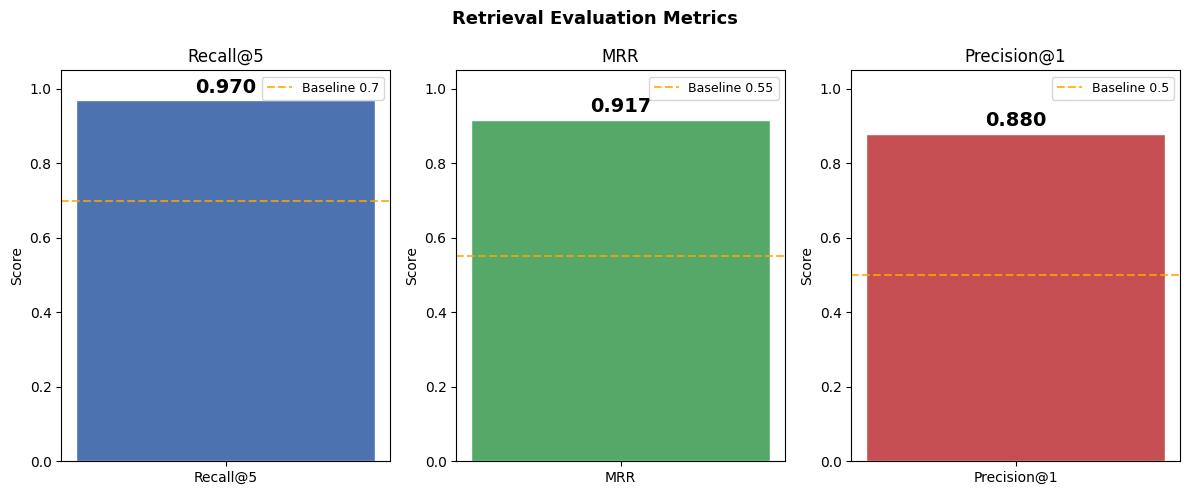

In [21]:
# CELL 22 — Metrics bar chart

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle("Retrieval Evaluation Metrics", fontsize=13, fontweight="bold")

names = ["Recall@5", "MRR", "Precision@1"]
vals  = [ev[n] for n in names]
bases = [0.70,      0.55,  0.50]
clrs  = ["#4C72B0", "#55A868", "#C44E52"]

for ax, name, val, base, clr in zip(axes, names, vals, bases, clrs):
    ax.bar([name], [val], color=clr, width=0.4, edgecolor="white")
    ax.axhline(base, color="orange", linestyle="--", alpha=0.8,
               label=f"Baseline {base}")
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.set_ylabel("Score")
    ax.text(0, val + 0.02, f"{val:.3f}",
            ha="center", fontsize=14, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Cell 23 — Interactive Q&A Widget

Creates a visual question-answering interface directly inside
the Colab notebook using ipywidgets.

Components:
  Textarea      → type your question here
  IntSlider     → choose how many source articles to retrieve (1-10)
  Dropdown      → optionally filter by category
  Ask button    → runs the full RAG pipeline on your question
  Clear button  → resets the input and output

The answer is displayed in a formatted HTML card showing:
  - The question
  - The generated answer in a blue highlighted box
  - Confidence score, latency, and number of sources
  - A collapsible "View Sources" section showing the actual
    news chunks that were retrieved and used to generate the answer

This widget is what you would demo to recruiters or in a GitHub README.
It shows the full system working in one interactive cell without
needing to run separate code blocks.

In [22]:
# CELL 23 — Simple Interactive Q&A (no widgets, GitHub safe)

def ask_question(question, top_k=5, category=None):
    """
    Run a question through the full RAG pipeline and print result.
    Call this function directly with any question.
    """
    print(f"\n{'='*55}")
    print(f"Q: {question}")

    r = rag.ask(question, top_k=top_k, category=category)

    if r["gate_passed"]:
        print(f"A: {r['answer']}")
        print(f"\n   Score    : {r['top_score']:.3f}")
        print(f"   Latency  : {r['latency_ms']:.0f}ms")
        print(f"   Sources  : {r['n_sources']}")
        print(f"\n   Top Sources:")
        for i, s in enumerate(r["sources"], 1):
            print(f"   [{i}] [{s['category']:10s}] score={s['score']:.3f}")
            print(f"       {s['text'][:120]}...")
    else:
        print(f"A: {r['answer']}")
        print(f"   Score={r['top_score']:.3f} — below threshold, no relevant news found")

    print(f"{'='*55}")
    return r


# ── Run these questions — edit freely ─────────────────────────────────────
ask_question("What are the latest developments in artificial intelligence?")
ask_question("How did the stock market perform recently?")
ask_question("What happened in major sports events?")
ask_question("What is NASA doing for space exploration?")

# To ask your own question:
# ask_question("your question here")
# ask_question("your question here", category="Sports")   # filter by category
# ask_question("your question here", top_k=3)             # fewer sources


Q: What are the latest developments in artificial intelligence?
A: I don't know

   Score    : 0.680
   Latency  : 230ms
   Sources  : 5

   Top Sources:
   [1] [Sci/Tech  ] score=0.680
       NASA Develops Robust Artificial Intelligence for Planetary Rovers NASA is planning to add a strong dose of artificial in...
   [2] [Sci/Tech  ] score=0.645
       Indian researcher designs revolutionary low cost PC for the poor Aug 17 - Professor Raj Reddy, an Indian researcher in a...
   [3] [Sci/Tech  ] score=0.641
       Bluetooth flying bot creates buzz The micro flyer is the next version of the robot by the Japanese technology firm that ...
   [4] [Sci/Tech  ] score=0.636
       Advanced Model of World #39;s Smallest Flying Microrobot from Epson Epson has long been engaged in the research and deve...
   [5] [Sci/Tech  ] score=0.627
       Indian researcher designs revolutionary low cost PC for the poor Professor Raj Reddy, an Indian researcher in artificial...

Q: How did the stock market p

{'question': 'What is NASA doing for space exploration?',
 'answer': 'Redesigning Rockets',
 'sources': [{'text': 'Redesigning Rockets: NASA Space Propulsion Finds a New Home (SPACE.com) SPACE.com - While the exploration of the Moon and other planets in our solar system is nbsp;exciting, the first task for astronauts and robots alike is to actually nbsp;get to those destinations.',
   'score': 0.70569908618927,
   'chunk_id': 102,
   'category': 'Sci/Tech',
   'article_id': 102},
  {'text': 'Water on Mars: More Evidences The Mars Exploration Rover mission is part of NASA #39;s Mars Exploration Program, a long-term effort of robotic exploration of the red planet.',
   'score': 0.703281819820404,
   'chunk_id': 6448,
   'category': 'Sci/Tech',
   'article_id': 6448},
  {'text': 'Nasa help for stem cell study UK tissue engineering experts are teaming up with NASA to find treatments for diseases back on Earth.',
   'score': 0.6946207880973816,
   'chunk_id': 232,
   'category': 'Sci/Tech',

## Cell 24 — Save and Reload the FAISS Index

Saves the three components needed to reload the pipeline
without re-embedding all articles from scratch.

What is saved:
  faiss.index    → the vector index containing all 384-dim embeddings
  metadata.pkl   → the per-chunk metadata (category, article_id, etc.)
  documents.pkl  → the actual text of every chunk

Why this matters:
  Encoding 10,000 chunks takes 60-90 seconds and requires the GPU.
  If your Colab session disconnects (which happens often on free tier)
  you would normally have to re-run the entire embedding step.
  By saving the index to disk and loading it back, you skip that step
  and go straight to running queries in a few seconds.

In a production system you would store these files in Google Cloud
Storage or S3 so the server can reload them instantly on startup
without needing to re-embed any documents.

The assert at the end confirms the reload was perfect —
the reloaded index has exactly the same number of vectors
as the original.

In [23]:
# CELL 24 — Save FAISS index + metadata to disk

faiss.write_index(index, "faiss.index")
with open("metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)
with open("documents.pkl", "wb") as f:
    pickle.dump(documents, f)

sz = os.path.getsize("faiss.index") / 1024**2
print(f"✅ Saved!")
print(f"   faiss.index  : {sz:.1f} MB")
print(f"   metadata.pkl : saved")
print(f"   documents.pkl: saved")

# Verify reload
idx2 = faiss.read_index("faiss.index")
with open("metadata.pkl",  "rb") as f: meta2 = pickle.load(f)
with open("documents.pkl", "rb") as f: docs2 = pickle.load(f)

assert idx2.ntotal == index.ntotal
print(f"\n✅ Reload verified — {idx2.ntotal:,} vectors intact")

✅ Saved!
   faiss.index  : 11.7 MB
   metadata.pkl : saved
   documents.pkl: saved

✅ Reload verified — 8,000 vectors intact


In [24]:
# Run this cell, then download the notebook
# It strips the broken widget metadata from the file

import json
import os

# Find the notebook file name
nb_files = [f for f in os.listdir("/content") if f.endswith(".ipynb")]

if nb_files:
    nb_path = f"/content/{nb_files[0]}"
    with open(nb_path, "r") as f:
        nb = json.load(f)

    # Remove widget state from metadata
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]

    # Remove widget output from each cell
    for cell in nb.get("cells", []):
        clean_outputs = []
        for output in cell.get("outputs", []):
            if output.get("output_type") == "display_data":
                data = output.get("data", {})
                if "application/vnd.jupyter.widget-view+json" in data:
                    continue   # skip widget outputs
            clean_outputs.append(output)
        cell["outputs"] = clean_outputs

    with open(nb_path, "w") as f:
        json.dump(nb, f, indent=1)

    print(f"✅ Fixed: {nb_path}")
    print(f"   Download it now: File → Download → Download .ipynb")
else:
    print("No .ipynb found. Save notebook first: File → Save (Ctrl+S)")

No .ipynb found. Save notebook first: File → Save (Ctrl+S)
